# Phase 4 — Coordinate-Free Complex Geometric Brownian Motion

This notebook validates the native complex exponential

\[
\mathcal Z_t
=
\mathcal Z_0
\exp\!\left(
\left[\left(\mu-\frac12\sigma^2\right)+i\omega\right]t
+(\sigma+i\beta)W_t
\right).
\]

Its modulus and continuous phase are

\[
|\mathcal Z_t|
=
|\mathcal Z_0|
e^{(\mu-\sigma^2/2)t+\sigma W_t},
\qquad
\Theta_t=\Theta_0+\omega t+\beta W_t.
\]

The experiments test exact identities, the complex Itô correction,
moments, covariance rank, Phase 3 equivalence, complex quadratic
variations, and Euler--Maruyama convergence. Cartesian coordinates are
used only for plots, never to define the process.

In [1]:
import os
import platform
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import nbformat
import numpy as np
import scipy

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "phase4_model.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "phase4_model.py").exists():
    raise RuntimeError("Run the notebook from the repository or notebooks directory")
sys.path.insert(0, str(PROJECT_ROOT))

from phase4_model import (
    ComplexGBMParameters,
    complex_bracket_rates,
    complex_moment,
    exact_path,
    exact_step,
    gbm_radius,
    log_polar_covariance,
    mixed_log_polar_moment,
    radial_moment,
    two_driver_path,
    unwrapped_phase,
)

BASE_SEED = 20260724
np.set_printoptions(precision=7, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")

print("Environment:", os.environ.get("CONDA_DEFAULT_ENV", "unknown"))
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Matplotlib:", matplotlib.__version__)
print("nbformat:", nbformat.__version__)

Environment: phase3-paper
Python: 3.12.13
Platform: Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43
NumPy: 2.5.1
SciPy: 1.18.0
Matplotlib: 3.11.1
nbformat: 5.10.4


## 1. Coefficient map and exact path

Define

\[
\kappa=\left(\mu-\frac12\sigma^2\right)+i\omega,
\qquad B=\sigma+i\beta.
\]

The ordinary exponent uses \(\kappa\), while the complex Itô SDE uses

\[
A=\kappa+\frac12B^2
=\mu-\frac12\beta^2+i(\omega+\sigma\beta).
\]

In [2]:
params = ComplexGBMParameters(
    mu=0.08,
    sigma=0.30,
    omega=0.70,
    beta=0.45,
)
z0 = 1.7 * np.exp(0.35j)

coefficient_residual = (
    params.sde_drift
    - 0.5 * params.diffusion**2
    - params.log_drift
)
print("log drift kappa:", params.log_drift)
print("SDE drift A:", params.sde_drift)
print("diffusion B:", params.diffusion)
print("A - B^2/2 - kappa:", coefficient_residual)
assert abs(coefficient_residual) < 1e-15

T_path = 4.0
n_path = 4000
h_path = T_path / n_path
rng_path = np.random.default_rng(BASE_SEED)
dW_path = np.sqrt(h_path) * rng_path.standard_normal(n_path)
W_path = np.concatenate(([0.0], np.cumsum(dW_path)))
t_path = np.linspace(0.0, T_path, n_path + 1)

z_path = exact_path(t_path, W_path, z0, params)
radius_reference = gbm_radius(t_path, W_path, abs(z0), params)
phase_reference = unwrapped_phase(t_path, W_path, np.angle(z0), params)

radius_error = np.max(np.abs(np.abs(z_path) - radius_reference))
phase_error = np.max(
    np.abs(np.unwrap(np.angle(z_path)) - phase_reference)
)

z_steps = np.empty_like(z_path)
z_steps[0] = z0
for index, increment in enumerate(dW_path):
    z_steps[index + 1] = exact_step(
        z_steps[index],
        h_path,
        increment,
        params,
    )
step_error = np.max(np.abs(z_steps - z_path))

print(f"Maximum modulus identity error: {radius_error:.3e}")
print(f"Maximum unwrapped-phase error: {phase_error:.3e}")
print(f"Maximum exact-step error: {step_error:.3e}")

assert radius_error < 2e-14
assert phase_error < 2e-13
assert step_error < 2e-12

log drift kappa: (0.035+0.7j)
SDE drift A: (-0.021250000000000005+0.835j)
diffusion B: (0.3+0.45j)
A - B^2/2 - kappa: 0j
Maximum modulus identity error: 8.882e-16
Maximum unwrapped-phase error: 4.441e-16
Maximum exact-step error: 8.750e-15


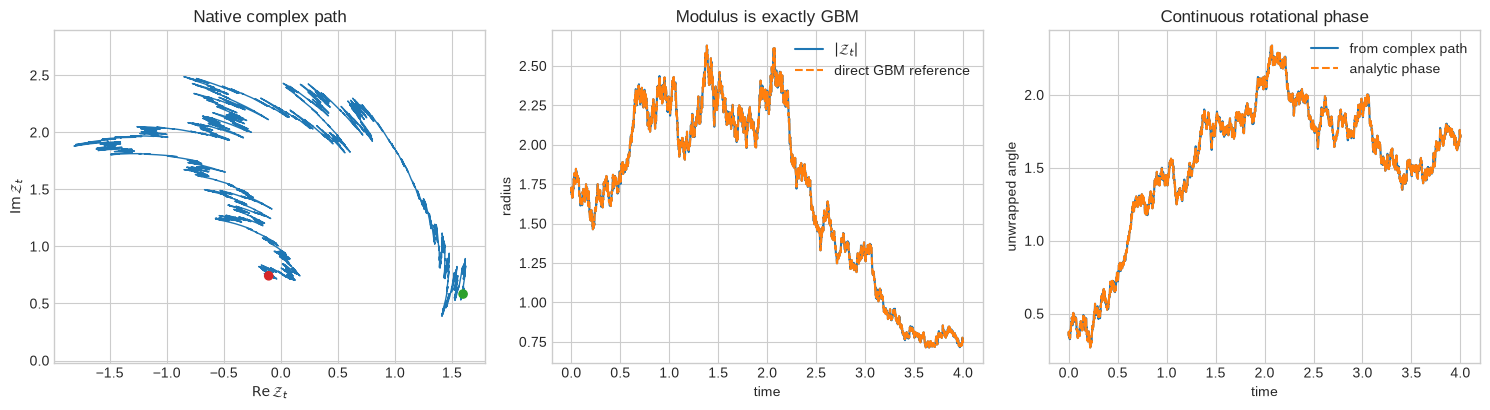

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].plot(z_path.real, z_path.imag, color="tab:blue", linewidth=1.0)
axes[0].scatter(
    [z_path.real[0], z_path.real[-1]],
    [z_path.imag[0], z_path.imag[-1]],
    c=["tab:green", "tab:red"],
    s=35,
    zorder=3,
)
axes[0].set_title("Native complex path")
axes[0].set_xlabel(r"$\operatorname{Re}\mathcal{Z}_t$")
axes[0].set_ylabel(r"$\operatorname{Im}\mathcal{Z}_t$")
axes[0].axis("equal")

axes[1].plot(t_path, np.abs(z_path), label=r"$|\mathcal{Z}_t|$")
axes[1].plot(
    t_path,
    radius_reference,
    "--",
    label="direct GBM reference",
)
axes[1].set_title("Modulus is exactly GBM")
axes[1].set_xlabel("time")
axes[1].set_ylabel("radius")
axes[1].legend()

axes[2].plot(t_path, np.unwrap(np.angle(z_path)), label="from complex path")
axes[2].plot(t_path, phase_reference, "--", label="analytic phase")
axes[2].set_title("Continuous rotational phase")
axes[2].set_xlabel("time")
axes[2].set_ylabel("unwrapped angle")
axes[2].legend()

fig.tight_layout()
plt.show()

## 2. Rotation parameter gallery

The same Brownian path is reused so changes in geometry are caused
only by \(\omega\) and \(\beta\).

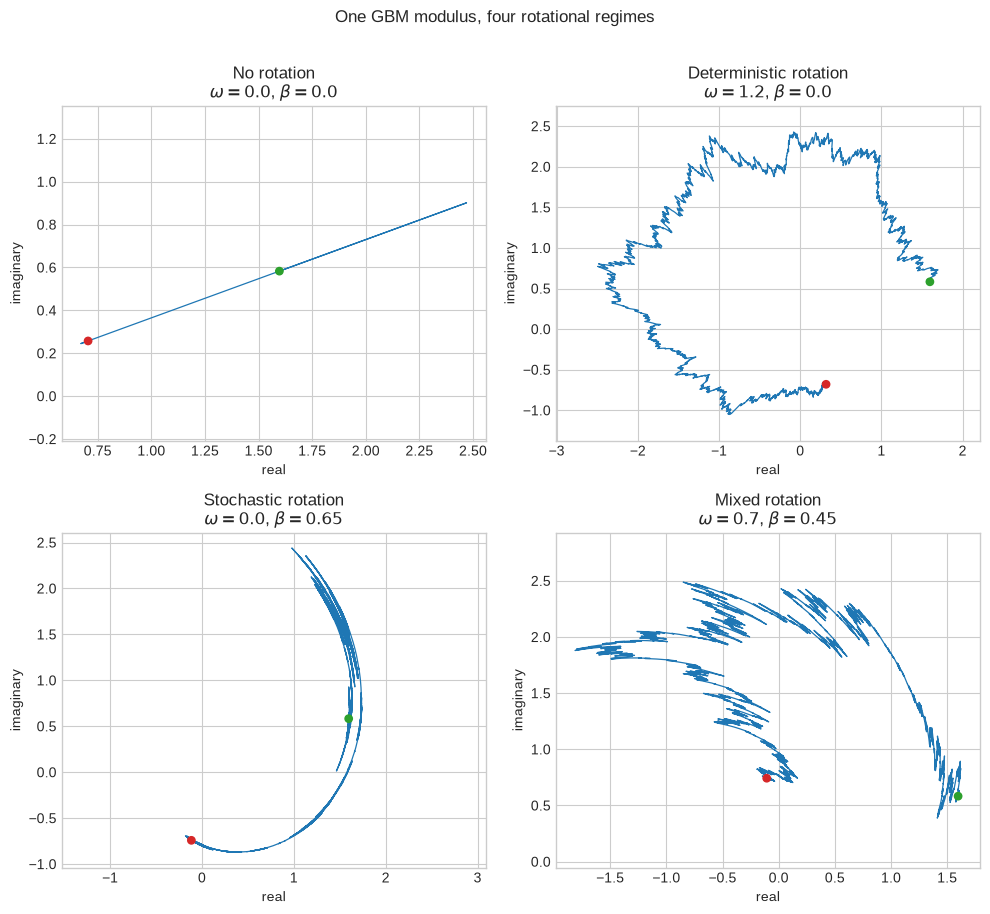

In [4]:
gallery = [
    ("No rotation", 0.0, 0.0),
    ("Deterministic rotation", 1.2, 0.0),
    ("Stochastic rotation", 0.0, 0.65),
    ("Mixed rotation", 0.7, 0.45),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for axis, (title, omega, beta) in zip(axes.flat, gallery):
    gallery_params = ComplexGBMParameters(
        mu=params.mu,
        sigma=params.sigma,
        omega=omega,
        beta=beta,
    )
    gallery_z = exact_path(t_path, W_path, z0, gallery_params)
    axis.plot(gallery_z.real, gallery_z.imag, linewidth=0.9)
    axis.scatter(
        [gallery_z.real[0], gallery_z.real[-1]],
        [gallery_z.imag[0], gallery_z.imag[-1]],
        c=["tab:green", "tab:red"],
        s=28,
        zorder=3,
    )
    axis.set_title(f"{title}\n$\\omega={omega}$, $\\beta={beta}$")
    axis.set_xlabel("real")
    axis.set_ylabel("imaginary")
    axis.axis("equal")

fig.suptitle("One GBM modulus, four rotational regimes", y=1.01)
fig.tight_layout()
plt.show()

## 3. Constant-modulus stress test

With \(\mu=\sigma=0\),

\[
\mathcal Z_t=\mathcal Z_0e^{i(\omega t+\beta W_t)}
\]

has constant modulus. Its Itô SDE requires the real drift
\(-\beta^2/2\). Omitting that drift produces deterministic radial
growth \(e^{\beta^2t/2}\). The counterfactual below deliberately keeps
the same deterministic \(i\omega\) drift so that only the missing Itô
correction changes; this imaginary term does not affect the modulus.

Constant-modulus maximum error: 4.441e-16
Wrong-SDE radius formula error: 3.553e-15
Wrong-SDE final radial growth factor: 5.053090


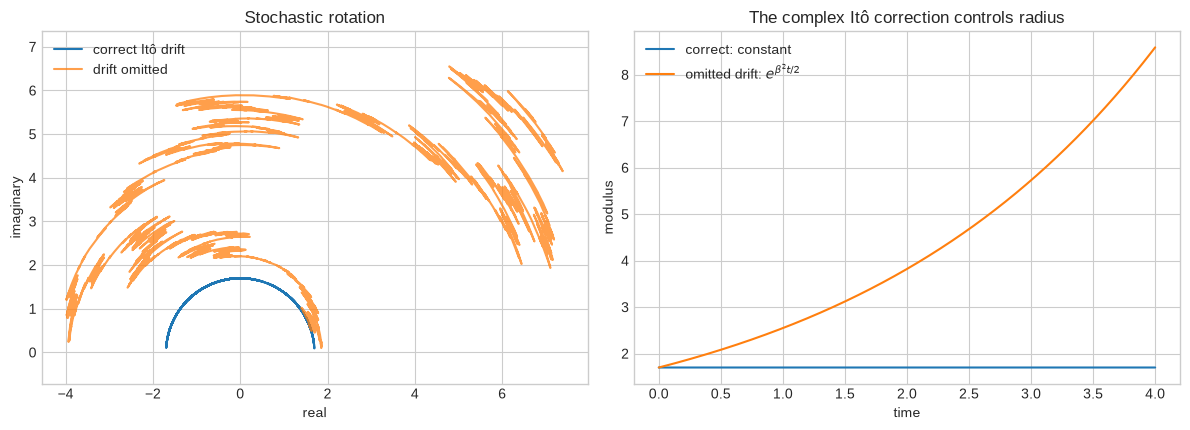

In [5]:
rotation_params = ComplexGBMParameters(
    mu=0.0,
    sigma=0.0,
    omega=0.8,
    beta=0.9,
)
z_rotation = exact_path(t_path, W_path, z0, rotation_params)
constant_radius_error = np.max(np.abs(np.abs(z_rotation) - abs(z0)))

wrong_no_ito_drift = z0 * np.exp(
    (0.5 * rotation_params.beta**2 + 1j * rotation_params.omega) * t_path
    + 1j * rotation_params.beta * W_path
)
expected_wrong_radius = abs(z0) * np.exp(
    0.5 * rotation_params.beta**2 * t_path
)
wrong_radius_error = np.max(
    np.abs(np.abs(wrong_no_ito_drift) - expected_wrong_radius)
)
wrong_final_growth = abs(wrong_no_ito_drift[-1]) / abs(z0)

print(f"Constant-modulus maximum error: {constant_radius_error:.3e}")
print(f"Wrong-SDE radius formula error: {wrong_radius_error:.3e}")
print(f"Wrong-SDE final radial growth factor: {wrong_final_growth:.6f}")

assert constant_radius_error < 2e-14
assert wrong_radius_error < 2e-13
assert np.isclose(
    wrong_final_growth,
    np.exp(0.5 * rotation_params.beta**2 * T_path),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].plot(
    z_rotation.real,
    z_rotation.imag,
    label="correct Itô drift",
)
axes[0].plot(
    wrong_no_ito_drift.real,
    wrong_no_ito_drift.imag,
    alpha=0.75,
    label="drift omitted",
)
axes[0].set_title("Stochastic rotation")
axes[0].set_xlabel("real")
axes[0].set_ylabel("imaginary")
axes[0].axis("equal")
axes[0].legend()

axes[1].plot(t_path, np.abs(z_rotation), label="correct: constant")
axes[1].plot(
    t_path,
    np.abs(wrong_no_ito_drift),
    label=r"omitted drift: $e^{\beta^2t/2}$",
)
axes[1].set_title("The complex Itô correction controls radius")
axes[1].set_xlabel("time")
axes[1].set_ylabel("modulus")
axes[1].legend()

fig.tight_layout()
plt.show()

## 4. One-driver rank versus two-driver rank

For one driver, the centered log-polar increment is

\[
\begin{pmatrix}\sigma\\\beta\end{pmatrix}\Delta W,
\]

so its covariance is an outer product of rank one. Independent radial
and angular Brownian motions produce a diagonal, rank-two comparator.

One-driver theoretical covariance:
[[0.09   0.135 ]
 [0.135  0.2025]]
One-driver empirical covariance:
[[0.0898792 0.1348188]
 [0.1348188 0.2022282]]
One-driver eigenvalues: [-0.         0.2921074]
Two-driver empirical covariance:
[[ 0.0898792 -0.0004942]
 [-0.0004942  0.202468 ]]
Two-driver eigenvalues: [0.089877  0.2024701]


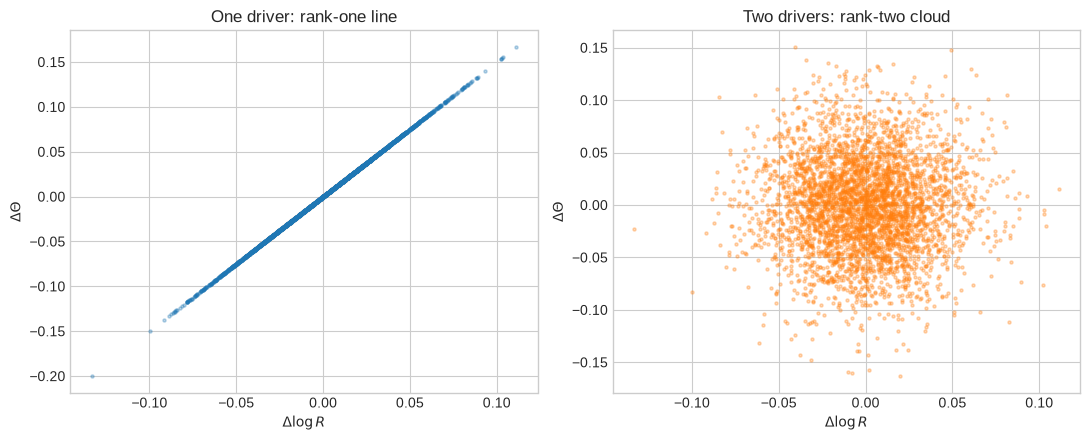

In [6]:
h_cov = 0.01
n_cov = 250_000
rng_cov = np.random.default_rng(BASE_SEED + 1)
dW_radial = np.sqrt(h_cov) * rng_cov.standard_normal(n_cov)
dW_angular = np.sqrt(h_cov) * rng_cov.standard_normal(n_cov)

increments_one = np.column_stack(
    (params.sigma * dW_radial, params.beta * dW_radial)
)
increments_two = np.column_stack(
    (params.sigma * dW_radial, params.beta * dW_angular)
)

covariance_one = np.cov(increments_one, rowvar=False, ddof=1) / h_cov
covariance_two = np.cov(increments_two, rowvar=False, ddof=1) / h_cov
covariance_theory = log_polar_covariance(params)
eigen_one = np.linalg.eigvalsh(covariance_one)
eigen_two = np.linalg.eigvalsh(covariance_two)

print("One-driver theoretical covariance:")
print(covariance_theory)
print("One-driver empirical covariance:")
print(covariance_one)
print("One-driver eigenvalues:", eigen_one)
print("Two-driver empirical covariance:")
print(covariance_two)
print("Two-driver eigenvalues:", eigen_two)

assert abs(eigen_one[0]) < 1e-12
assert eigen_one[1] > 0.25
assert eigen_two[0] > 0.08
assert eigen_two[1] > 0.18

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sample = slice(0, 4000)
axes[0].scatter(
    increments_one[sample, 0],
    increments_one[sample, 1],
    s=5,
    alpha=0.3,
)
axes[0].set_title("One driver: rank-one line")
axes[0].set_xlabel(r"$\Delta\log R$")
axes[0].set_ylabel(r"$\Delta\Theta$")

axes[1].scatter(
    increments_two[sample, 0],
    increments_two[sample, 1],
    s=5,
    alpha=0.3,
    color="tab:orange",
)
axes[1].set_title("Two drivers: rank-two cloud")
axes[1].set_xlabel(r"$\Delta\log R$")
axes[1].set_ylabel(r"$\Delta\Theta$")

fig.tight_layout()
plt.show()

## 5. Monte Carlo moments

The analytic radial moment is

\[
\mathbb E[R_t^p]
=
R_0^p
\exp\!\left(
p\mu t+\frac12p(p-1)\sigma^2t
\right),
\]

and the complex moment is

\[
\mathbb E[\mathcal Z_t^n]
=
\mathcal Z_0^n
\exp\!\left(
n\kappa t+\frac12n^2B^2t
\right).
\]

In [7]:
T_mc = 1.5
n_mc = 300_000
rng_mc = np.random.default_rng(BASE_SEED + 2)
W_terminal = np.sqrt(T_mc) * rng_mc.standard_normal(n_mc)
z_terminal = z0 * np.exp(
    params.log_drift * T_mc + params.diffusion * W_terminal
)
r_terminal = np.abs(z_terminal)
theta_increment = (
    params.omega * T_mc + params.beta * W_terminal
)

def real_z_score(samples, theory):
    estimate = np.mean(samples)
    standard_error = np.std(samples, ddof=1) / np.sqrt(samples.size)
    return estimate, standard_error, (estimate - theory) / standard_error

def complex_z_scores(samples, theory):
    estimate = np.mean(samples)
    se_real = np.std(samples.real, ddof=1) / np.sqrt(samples.size)
    se_imag = np.std(samples.imag, ddof=1) / np.sqrt(samples.size)
    z_real = (estimate.real - theory.real) / se_real
    z_imag = (estimate.imag - theory.imag) / se_imag
    return estimate, se_real, se_imag, z_real, z_imag

radial_theory = radial_moment(abs(z0), T_mc, 2.0, params)
radial_stats = real_z_score(r_terminal**2, radial_theory)

complex_theory = complex_moment(z0, T_mc, 1, params)
complex_stats = complex_z_scores(z_terminal, complex_theory)

mixed_samples = r_terminal * np.exp(1j * theta_increment)
mixed_theory = mixed_log_polar_moment(
    abs(z0),
    T_mc,
    1.0,
    1.0,
    params,
)
mixed_stats = complex_z_scores(mixed_samples, mixed_theory)

print(
    "E[R_T^2]: estimate={:.7f}, theory={:.7f}, SE={:.3e}, z={:.3f}".format(
        radial_stats[0],
        radial_theory,
        radial_stats[1],
        radial_stats[2],
    )
)
print(
    "E[Z_T]: estimate={}, theory={}, z(real,imag)=({:.3f},{:.3f})".format(
        complex_stats[0],
        complex_theory,
        complex_stats[3],
        complex_stats[4],
    )
)
print(
    "mixed moment: estimate={}, theory={}, z(real,imag)=({:.3f},{:.3f})".format(
        mixed_stats[0],
        mixed_theory,
        mixed_stats[3],
        mixed_stats[4],
    )
)

assert abs(radial_stats[2]) < 4.5
assert max(abs(complex_stats[3]), abs(complex_stats[4])) < 4.5
assert max(abs(mixed_stats[3]), abs(mixed_stats[4])) < 4.5

E[R_T^2]: estimate=4.1984821, theory=4.2049252, SE=6.479e-03, z=-0.994
E[Z_T]: estimate=(-0.05039675888038092+1.6437556328068645j), theory=(-0.05219664773107041+1.645839528004551j), z(real,imag)=(0.949,-1.770)
mixed moment: estimate=(0.516298862373843+1.5613801261708882j), theory=(0.5153226589956008+1.5639548583965934j), z(real,imag)=(0.629,-1.605)


## 6. Phase 3 is a constrained subfamily

For \(c=1+i\gamma\) and GBM log-return

\[
L_t=\left(\mu-\frac12\sigma^2\right)t+\sigma W_t,
\]

Phase 3 gives \(\mathcal Z_t=\mathcal Z_0e^{cL_t}\). It agrees with
Phase 4 only when

\[
\beta=\gamma\sigma,\qquad
\omega=\gamma\left(\mu-\frac12\sigma^2\right).
\]

Phase 3 restricted-subfamily error: 6.661e-16
General Phase 4 time-dependent spiral residual: 0.647500


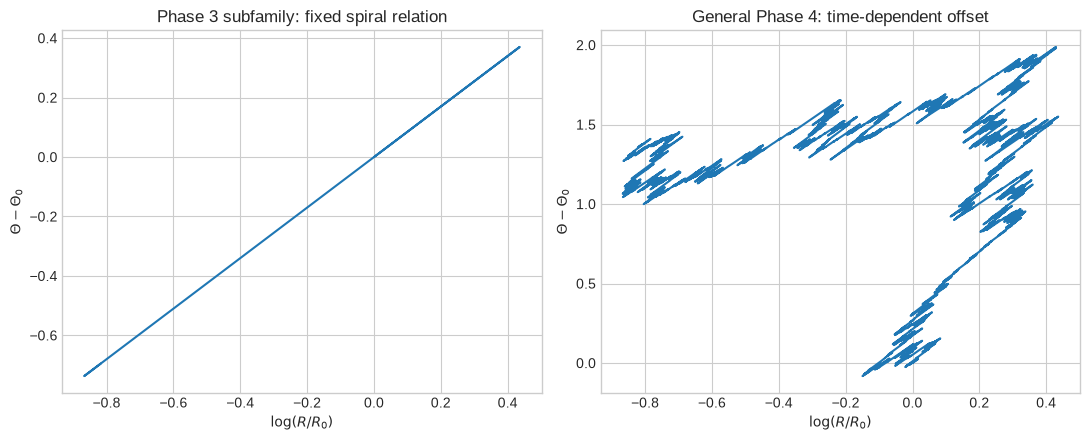

In [8]:
gamma = 0.85
phase3_params = ComplexGBMParameters(
    mu=params.mu,
    sigma=params.sigma,
    omega=gamma * (params.mu - 0.5 * params.sigma**2),
    beta=gamma * params.sigma,
)
log_return = (
    (params.mu - 0.5 * params.sigma**2) * t_path
    + params.sigma * W_path
)
z_phase3 = z0 * np.exp((1.0 + 1j * gamma) * log_return)
z_phase4_restricted = exact_path(
    t_path,
    W_path,
    z0,
    phase3_params,
)
phase3_equivalence_error = np.max(
    np.abs(z_phase3 - z_phase4_restricted)
)

free_spiral_residual = (
    params.omega
    - (params.beta / params.sigma)
    * (params.mu - 0.5 * params.sigma**2)
)

print(f"Phase 3 restricted-subfamily error: {phase3_equivalence_error:.3e}")
print(f"General Phase 4 time-dependent spiral residual: {free_spiral_residual:.6f}")

assert phase3_equivalence_error < 2e-13
assert not np.isclose(free_spiral_residual, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(
    np.log(np.abs(z_phase4_restricted) / abs(z0)),
    np.unwrap(np.angle(z_phase4_restricted)) - np.angle(z0),
)
axes[0].set_title("Phase 3 subfamily: fixed spiral relation")
axes[0].set_xlabel(r"$\log(R/R_0)$")
axes[0].set_ylabel(r"$\Theta-\Theta_0$")

axes[1].plot(
    np.log(np.abs(z_path) / abs(z0)),
    np.unwrap(np.angle(z_path)) - np.angle(z0),
)
axes[1].set_title("General Phase 4: time-dependent offset")
axes[1].set_xlabel(r"$\log(R/R_0)$")
axes[1].set_ylabel(r"$\Theta-\Theta_0$")

fig.tight_layout()
plt.show()

## 7. Euler--Maruyama strong convergence

Euler--Maruyama advances the complex SDE with \(A\), not the
compensated exponent drift \(\kappa\):

\[
Z_{n+1}^{\rm EM}
=
Z_n^{\rm EM}(1+Ah+B\Delta W_n).
\]

Shared fine Brownian paths are aggregated to each coarser step size.

step sizes: [0.0625    0.03125   0.015625  0.0078125 0.0039062]
mean strong errors: [0.0890496 0.0572328 0.0397036 0.0274716 0.0193116]
fitted strong-convergence slope: 0.5469


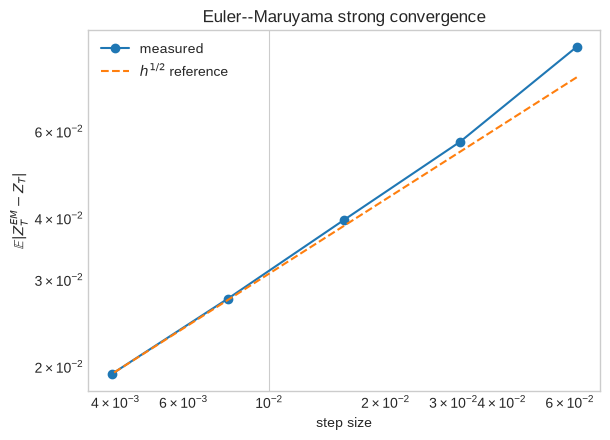

In [9]:
T_em = 1.0
n_fine = 2048
n_em_paths = 3500
rng_em = np.random.default_rng(BASE_SEED + 3)
dW_fine = (
    np.sqrt(T_em / n_fine)
    * rng_em.standard_normal((n_em_paths, n_fine))
)
W_em_terminal = np.sum(dW_fine, axis=1)
exact_em_terminal = z0 * np.exp(
    params.log_drift * T_em
    + params.diffusion * W_em_terminal
)

step_counts = np.array([16, 32, 64, 128, 256])
strong_errors = []
for n_steps in step_counts:
    block = n_fine // n_steps
    coarse_increments = dW_fine.reshape(
        n_em_paths,
        n_steps,
        block,
    ).sum(axis=2)
    h = T_em / n_steps
    z_em = np.full(n_em_paths, z0, dtype=np.complex128)
    for column in range(n_steps):
        z_em *= (
            1.0
            + params.sde_drift * h
            + params.diffusion * coarse_increments[:, column]
        )
    strong_errors.append(np.mean(np.abs(z_em - exact_em_terminal)))

strong_errors = np.asarray(strong_errors)
step_sizes = T_em / step_counts
convergence_slope = np.polyfit(
    np.log(step_sizes),
    np.log(strong_errors),
    1,
)[0]

print("step sizes:", step_sizes)
print("mean strong errors:", strong_errors)
print(f"fitted strong-convergence slope: {convergence_slope:.4f}")

assert np.all(np.diff(strong_errors) < 0.0)
assert 0.43 < convergence_slope < 0.60

fig, axis = plt.subplots(figsize=(6.2, 4.5))
axis.loglog(step_sizes, strong_errors, "o-", label="measured")
reference = strong_errors[-1] * (step_sizes / step_sizes[-1]) ** 0.5
axis.loglog(step_sizes, reference, "--", label=r"$h^{1/2}$ reference")
axis.set_xlabel("step size")
axis.set_ylabel(r"$\mathbb{E}|Z_T^{EM}-Z_T|$")
axis.set_title("Euler--Maruyama strong convergence")
axis.legend()
fig.tight_layout()
plt.show()

## 8. Complex quadratic variations

The two brackets are

\[
d[\mathcal Z,\mathcal Z]_t
=B^2\mathcal Z_t^2dt,
\qquad
d[\mathcal Z,\overline{\mathcal Z}]_t
=|B|^2|\mathcal Z_t|^2dt.
\]

A fine-grid realized quadratic variation is compared with the
corresponding left-point integrals.

In [10]:
T_qv = 1.5
n_qv = 65_536
h_qv = T_qv / n_qv
rng_qv = np.random.default_rng(BASE_SEED + 4)
dW_qv = np.sqrt(h_qv) * rng_qv.standard_normal(n_qv)
W_qv = np.concatenate(([0.0], np.cumsum(dW_qv)))
t_qv = np.linspace(0.0, T_qv, n_qv + 1)
z_qv = exact_path(t_qv, W_qv, z0, params)
dz_qv = np.diff(z_qv)

realized_bilinear = np.sum(dz_qv**2)
realized_hermitian = np.sum(np.abs(dz_qv) ** 2)
predicted_bilinear = np.sum(
    params.diffusion**2 * z_qv[:-1] ** 2 * h_qv
)
predicted_hermitian = np.sum(
    abs(params.diffusion) ** 2 * np.abs(z_qv[:-1]) ** 2 * h_qv
)

bilinear_relative_error = (
    abs(realized_bilinear - predicted_bilinear)
    / abs(predicted_bilinear)
)
hermitian_relative_error = (
    abs(realized_hermitian - predicted_hermitian)
    / predicted_hermitian
)
bracket_rate_check = complex_bracket_rates(z_qv[100], params)

print(f"Bilinear QV relative error: {bilinear_relative_error:.4%}")
print(f"Hermitian QV relative error: {hermitian_relative_error:.4%}")
print("Example bracket rates:", bracket_rate_check)

assert bilinear_relative_error < 0.08
assert hermitian_relative_error < 0.04
assert bracket_rate_check[1] > 0.0

Bilinear QV relative error: 0.6998%
Hermitian QV relative error: 0.3648%
Example bracket rates: ((-0.7490269274390544+0.3870574629787237j), 0.843122065703606)


## 9. Independent two-driver boundary

The independent comparator

\[
\mathcal Z_t^{(2)}
=
\mathcal Z_0
\exp\!\left(
\left[\left(\mu-\frac12\sigma^2\right)+i\omega\right]t
+\sigma W_t^{(r)}+i\beta W_t^{(\theta)}
\right)
\]

retains the same GBM modulus but changes the log-polar covariance from
rank one to rank two. It is not an equivalent one-driver
representation and is not ordinary planar Brownian motion.

Two-driver GBM-modulus error: 8.882e-16


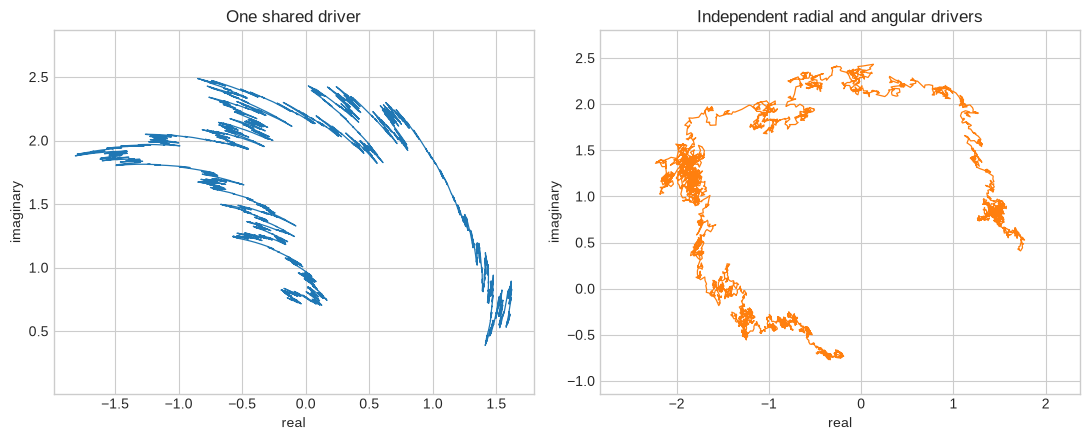

In [11]:
rng_two = np.random.default_rng(BASE_SEED + 5)
dW_theta_path = np.sqrt(h_path) * rng_two.standard_normal(n_path)
W_theta_path = np.concatenate(([0.0], np.cumsum(dW_theta_path)))
z_two = two_driver_path(
    t_path,
    W_path,
    W_theta_path,
    z0,
    params,
)
two_driver_radius_error = np.max(
    np.abs(np.abs(z_two) - radius_reference)
)

print(f"Two-driver GBM-modulus error: {two_driver_radius_error:.3e}")
assert two_driver_radius_error < 2e-14

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(z_path.real, z_path.imag, linewidth=0.9)
axes[0].set_title("One shared driver")
axes[0].set_xlabel("real")
axes[0].set_ylabel("imaginary")
axes[0].axis("equal")

axes[1].plot(z_two.real, z_two.imag, linewidth=0.9, color="tab:orange")
axes[1].set_title("Independent radial and angular drivers")
axes[1].set_xlabel("real")
axes[1].set_ylabel("imaginary")
axes[1].axis("equal")

fig.tight_layout()
plt.show()

## 10. Verified synthesis

The computations support the analytic conclusions:

- the native complex exponent has an exact GBM modulus;
- its imaginary exponent produces deterministic and stochastic
  rotation;
- the complex SDE drift contains both
  \(-\beta^2/2\) and \(i\sigma\beta\) corrections;
- the exact random-walk step combines \(h\) and
  \(\sqrt h\,\xi_n\) in one exponent;
- Phase 3 is the fixed-spiral parameter subfamily;
- one shared Brownian driver has rank-one log-polar noise; and
- independent radial and angular noise requires a second driver.

These experiments verify formulas; the accompanying Markdown notes
contain the proofs.

In [12]:
summary = {
    "modulus_error": radius_error,
    "phase_error": phase_error,
    "exact_step_error": step_error,
    "constant_modulus_error": constant_radius_error,
    "one_driver_min_eigenvalue": eigen_one[0],
    "two_driver_min_eigenvalue": eigen_two[0],
    "radial_moment_z_score": radial_stats[2],
    "complex_mean_z_scores": (complex_stats[3], complex_stats[4]),
    "phase3_equivalence_error": phase3_equivalence_error,
    "em_strong_slope": convergence_slope,
    "bilinear_qv_relative_error": bilinear_relative_error,
    "hermitian_qv_relative_error": hermitian_relative_error,
    "two_driver_radius_error": two_driver_radius_error,
}
for key, value in summary.items():
    print(f"{key}: {value}")
print("All Phase 4 notebook assertions passed.")

modulus_error: 8.881784197001252e-16
phase_error: 4.440892098500626e-16
exact_step_error: 8.750360656168091e-15
constant_modulus_error: 4.440892098500626e-16
one_driver_min_eigenvalue: -1.249000902703301e-16
two_driver_min_eigenvalue: 0.08987703830839887
radial_moment_z_score: -0.9944019434284168
complex_mean_z_scores: (np.float64(0.9494502504859922), np.float64(-1.7698898882308824))
phase3_equivalence_error: 6.661338147750939e-16
em_strong_slope: 0.5469182924164009
bilinear_qv_relative_error: 0.0069976819411781055
hermitian_qv_relative_error: 0.00364797893350375
two_driver_radius_error: 8.881784197001252e-16
All Phase 4 notebook assertions passed.
